# Effectiveness of thrombolysis and thrombectomy in early (6hr) arrivals of non-mild stroke - discharge mRS 0-2

## Selection criteria

* Arrival within 6 hours of known stroke onset time
* Thrombectomy, if given, given within 12 hours
* Thrombolysis, if given, given within 6 hours
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity > 5 (or labelled as LVO)

## Outcome of interest

* Discharge mRS 0-5 (survival).

## Key features of interest

* Onset to thrombolysis time
* Onset to thrombectomy time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Methodology steps

* Select patients by above criteria
* Select features by above criteria
* Split data in 5 sets, where 80% of data is used to train a model, and tets results are generated for the remaining 20% (each patient is in a single test set)
* Train 5 models
* For each model get outcome results for the tets set
* For each model, for patients treated with thrombolysis or thrombectomy, get counterfactual outcomes if they had no treatment
* Calculate the difference between actual outcome and (counterfactual) no-treatment outcomes for treated patients
* Analyse resuls for patients who 1) received thrombectomy only, 2) thrombolysis only, 3) thrombolysis or thrombectomy *

*Note - though the analysis is by different groups, the models are fitted to all groups (no treatment, thrombolysis alone, thrombectomy alone, thrombolysis + thrombectomy).

## Load modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

## Define mRS outcome target

In [2]:
mrs_target = 5 # Model will set y as being less than or equal to this value

## Load and filter data

In [3]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]


# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")


Initial data shape: (452863, 70)
Final data shape: (76337, 70)
Number of patients with thrombectomy: 4645
Number of patients with both thrombolysis and thrombectomy: 2898
Number of patients with only thrombectomy: 1747
Number of patients with thrombolysis: 34182
Number of patients with only thrombolysis: 31284


In [4]:
# Convert times to thrombolysis and thrombectomy based on variable cutoff

treatment_groups = [
    'none',
    'early_ivt_only',
    'late_ivt_only',
    'early_mt_only',
    'late_mt_only',
    'early_both',
    'late_both',
    'early_ivt_late_mt'
]

data['treatment_group'] = 'none'

cutoff = 180

ivt = data["onset_to_thrombolysis_time"]
mt = data["onset_to_thrombectomy_time"]
sentinel = 99999

# Boolean masks (vectorized; avoids ambiguous Series truth-value errors)
ivt_treated = ivt < sentinel
mt_treated = mt < sentinel
ivt_early = ivt <= cutoff
ivt_late = (ivt > cutoff) & ivt_treated
mt_early = mt <= cutoff
mt_late = (mt > cutoff) & mt_treated

data.loc[ivt_early & ~mt_treated, "treatment_group"] = "early_ivt_only"
data.loc[ivt_late & ~mt_treated, "treatment_group"] = "late_ivt_only"
data.loc[mt_early & ~ivt_treated, "treatment_group"] = "early_mt_only"
data.loc[mt_late & ~ivt_treated, "treatment_group"] = "late_mt_only"
data.loc[ivt_early & mt_early, "treatment_group"] = "early_both"
data.loc[ivt_late & mt_late, "treatment_group"] = "late_both"
data.loc[ivt_early & mt_late, "treatment_group"] = "early_ivt_late_mt"


# Show mean, standard deviation, and n, for times to thrombolysis and thrombectomy in each group
grouped_times = data.groupby('treatment_group')[['onset_to_thrombolysis_time', 'onset_to_thrombectomy_time']]
times_summary = grouped_times.agg(['mean', 'std', 'count'])
# Shorten the column names for better readability
times_summary.columns = ['_'.join(col).strip() for col in times_summary.columns.values]
times_summary = times_summary.round(0).astype(int)
times_summary

,onset_to_thrombolysis_time_mean,onset_to_thrombolysis_time_std,onset_to_thrombolysis_time_count,onset_to_thrombectomy_time_mean,onset_to_thrombectomy_time_std,onset_to_thrombectomy_time_count
treatment_group,,,,,,
early_both,118,28,1685,134,29,1685
early_ivt_late_mt,153,25,423,242,102,423
early_ivt_only,133,29,19525,99999,0,19525
early_mt_only,99999,0,773,130,34,773
late_both,225,37,790,261,73,790
late_ivt_only,229,35,11759,99999,0,11759
late_mt_only,99999,0,974,310,112,974
none,99999,0,40408,99999,0,40408


In [5]:
non_categorical_features = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
]

categorical_features = [
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

# Ensure categorical columns are pandas categorical dtype for XGBoost
for col in categorical_features:
    data[col] = data[col].replace("", "Empty")
    data[col] = data[col].astype("category")

# Ensure non-categorical columns are numeric
for col in non_categorical_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

X_fields = non_categorical_features + categorical_features

In [6]:
## Create 5 k-fold splits

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data[X_fields]
y = (data['discharge_disability'] <= mrs_target).astype(int)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []

for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]
    
    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

## Train and test models

In [8]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]
    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 2.3
    )
    # Train model
    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.7877, Balanced Accuracy = 0.6851
Split 2: AUC = 0.7840, Balanced Accuracy = 0.6749
Split 3: AUC = 0.7880, Balanced Accuracy = 0.6735
Split 4: AUC = 0.7893, Balanced Accuracy = 0.6788
Split 5: AUC = 0.7884, Balanced Accuracy = 0.6771


In [9]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred = test_y_preds[split]
    
    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()
    
    print(
        f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, "
        f"Predicted positive rate = {predicted_pos_rate:.4f}"
    )

Split 1: Actual positive rate = 0.8367, Predicted positive rate = 0.8228
Split 2: Actual positive rate = 0.8367, Predicted positive rate = 0.8278
Split 3: Actual positive rate = 0.8368, Predicted positive rate = 0.8333
Split 4: Actual positive rate = 0.8368, Predicted positive rate = 0.8302
Split 5: Actual positive rate = 0.8368, Predicted positive rate = 0.8233


## Predict counterfactual outcomes

In [10]:
counter_factuals = []

for split in range(5):
    # Get model and data
    model = models[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]

    # Get index of patients who received thrombectomy or thrombolysis
    treated_indices = test_X[test_X['treatment_group'] != 'none'].index

    # Get X and y for these patients
    thrombectomy_X = test_X.loc[treated_indices]
    thrombectomy_y = test_y.loc[treated_indices]

    # Get predicted probabilities for these patients
    y_probs = model.predict_proba(thrombectomy_X)[:, 1]
    
    # No treatment scenario: 
    no_treatment_X = thrombectomy_X.copy(deep=True)
    no_treatment_X['treatment_group'] = 'none'
    # Keep categorical dtypes consistent before prediction
    no_treatment_X["treatment_group"] = pd.Categorical(
        ["none"] * len(no_treatment_X),
        categories=test_X["treatment_group"].cat.categories
    )
    for col in categorical_features:
        no_treatment_X[col] = no_treatment_X[col].astype("category")

    y_probs_no_treatment = model.predict_proba(no_treatment_X[X_fields])[:, 1]

    # Combine X, y, and store the counterfactuals for this split
    counter_factuals_split = thrombectomy_X.copy(deep=True)
    counter_factuals_split.insert(0, 'patient_index', treated_indices)
    counter_factuals_split['actual_y'] = thrombectomy_y
    counter_factuals_split['y_prob_treated'] = y_probs
    counter_factuals_split['y_prob_no_treatment'] = y_probs_no_treatment
    counter_factuals_split['treatment_diff_prob'] = y_probs - y_probs_no_treatment
    counter_factuals.append(counter_factuals_split)

# Combine all counterfactuals into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

# Convert probabilities to odds and log-odds (clip to avoid divide-by-zero / log(0))
eps = 1e-6
treated_prob = counter_factuals_df["y_prob_treated"].clip(eps, 1.0 - eps)
no_treatment_prob = counter_factuals_df["y_prob_no_treatment"].clip(eps, 1.0 - eps)

counter_factuals_df["odds_treated"] = treated_prob / (1.0 - treated_prob)
counter_factuals_df["odds_no_treatment"] = no_treatment_prob / (1.0 - no_treatment_prob)

counter_factuals_df["log_odds_treated"] = np.log(counter_factuals_df["odds_treated"])
counter_factuals_df["log_odds_no_treatment"] = np.log(
    counter_factuals_df["odds_no_treatment"]
)

In [11]:
from scipy import stats

# Calculate log-odds difference per patient
counter_factuals_df['log_odds_diff'] = counter_factuals_df['log_odds_treated'] - counter_factuals_df['log_odds_no_treatment']

# Calculate mean, SD and confidence intervals for treatment effect (log-odds difference) by treatment group
grouped = counter_factuals_df.groupby('treatment_group')['log_odds_diff']

treatment_effects_df = pd.DataFrame({
    'treatment_effect': grouped.mean(),
    'treatment_effect_sd': grouped.std(),
    'n': grouped.count()
})

treatment_effects_df["confidence_interval"] = (
    1.96 * treatment_effects_df["treatment_effect_sd"] / np.sqrt(treatment_effects_df["n"])
)

# Calculate P value using z-test (z-score vs 0, i.e. no treatment effect) and two-tailed test
treatment_effects_df["z_score"] = (
    treatment_effects_df["treatment_effect"]
    / (treatment_effects_df["treatment_effect_sd"] / np.sqrt(treatment_effects_df["n"]))
)
treatment_effects_df["p_value"] = 2 * (1 - stats.norm.cdf(np.abs(treatment_effects_df["z_score"])))

treatment_effects_df = treatment_effects_df.drop(columns='n').round(4)
treatment_effects_df


,treatment_effect,treatment_effect_sd,confidence_interval,z_score,p_value
treatment_group,,,,,
early_both,1.1941,0.9086,0.0434,53.9467,0.0
early_ivt_late_mt,0.9739,0.9663,0.0921,20.7273,0.0
early_ivt_only,0.5398,0.6107,0.0086,123.5016,0.0
early_mt_only,0.8069,0.9109,0.0642,24.6285,0.0
late_both,1.1912,1.0078,0.0703,33.2216,0.0
late_ivt_only,0.3037,0.6158,0.0111,53.4772,0.0
late_mt_only,0.5054,0.8702,0.0547,18.1270,0.0


In [12]:
# Combine treatment effects with times summary
combined_summary = treatment_effects_df.join(times_summary, how='left').T
combined_summary
# Save the combined summary to a CSV file
combined_summary.to_csv(f"./output/treatment_group_effects_summary_{mrs_target}.csv", index=True)

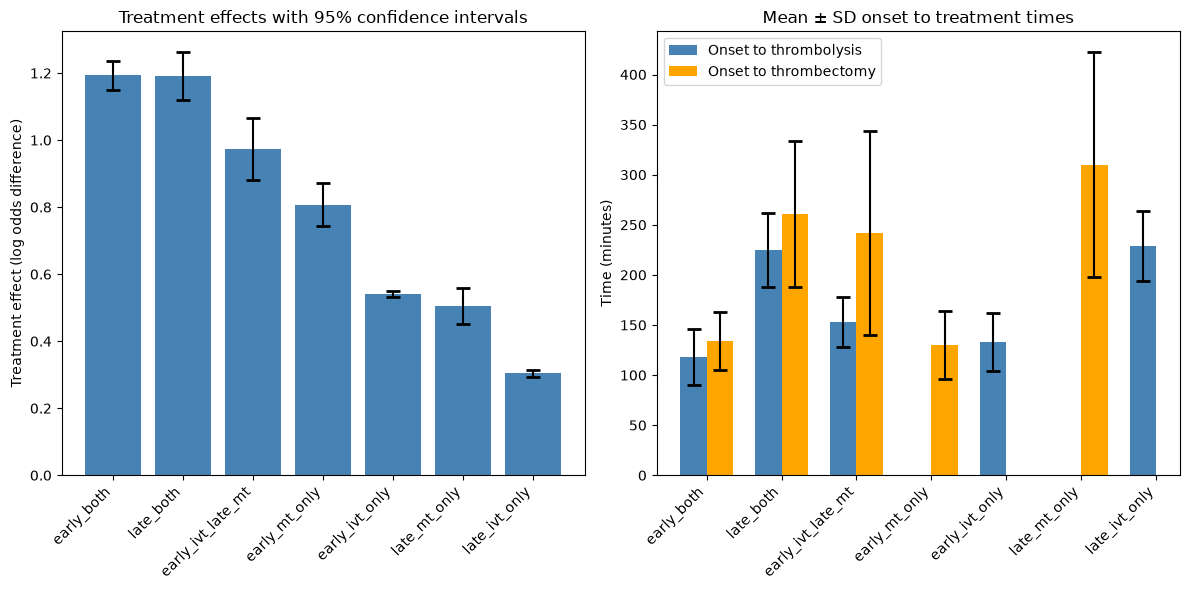

In [13]:
# Create a chart of treatment effects with 95% confidence intervals as error bars
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Treatment effects with 95% confidence intervals
ax = axes[0]
sorted_groups = treatment_effects_df.sort_values(by='treatment_effect', ascending=False)
ax.bar(
    x=sorted_groups.index,
    height=sorted_groups['treatment_effect'],
    yerr=sorted_groups['confidence_interval'],
    color='steelblue',
    ecolor='black',
    capsize=5,
    error_kw={'capthick': 2}
)
ax.set_ylabel("Treatment effect (log odds difference)")
ax.set_title("Treatment effects with 95% confidence intervals")
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')

# Plot 2: Mean and SD of times to thrombolysis and thrombectomy
ax2 = axes[1]
sentinel = 99999

# Filter times_summary to only groups in sorted_groups order
ts = times_summary.loc[sorted_groups.index]

ivt_mean = ts['onset_to_thrombolysis_time_mean'].where(ts['onset_to_thrombolysis_time_mean'] < sentinel)
ivt_std = ts['onset_to_thrombolysis_time_std'].where(ts['onset_to_thrombolysis_time_mean'] < sentinel)
mt_mean = ts['onset_to_thrombectomy_time_mean'].where(ts['onset_to_thrombectomy_time_mean'] < sentinel)
mt_std = ts['onset_to_thrombectomy_time_std'].where(ts['onset_to_thrombectomy_time_mean'] < sentinel)

x = range(len(sorted_groups))
width = 0.35

ax2.bar(
    [i - width/2 for i in x],
    ivt_mean,
    width,
    yerr=ivt_std,
    label='Onset to thrombolysis',
    color='steelblue',
    ecolor='black',
    capsize=5,
    error_kw={'capthick': 2}
)
ax2.bar(
    [i + width/2 for i in x],
    mt_mean,
    width,
    yerr=mt_std,
    label='Onset to thrombectomy',
    color='orange',
    ecolor='black',
    capsize=5,
    error_kw={'capthick': 2}
)
ax2.set_xticks(list(x))
ax2.set_xticklabels(sorted_groups.index, rotation=45, ha='right')
ax2.set_ylabel("Time (minutes)")
ax2.set_title("Mean ± SD onset to treatment times")
ax2.legend()
plt.tight_layout()
plt.savefig(f'./output/treatment_effect_groups_mrs_{mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()
